In [1]:
import numpy as np
from scipy.signal import cont2discrete

from config.matrizes_config import matrizes
from S_MPC import matriz_S
from Yr_MPC import alvo
from Y0_MPC import y_0
import casadi as cs
from config.config import values
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def mu(S, params):
    # Tx. específica de crescimento

    if not np.isfinite(S):
        raise FloatingPointError(f"S virou NaN/Inf dentro de mu: S={S}")

    if S <= -params["Ks"]:
        raise FloatingPointError(
            f"S chegou perto da singularidade de Monod: S={S}, Ks={params['Ks']}"
        )
    
    mu = (params["Mi_m"]*S)/(params["Ks"] + S)
    return mu


def bioreactor_model(states, u, params):
    X, S = states
    D, Sf = u

    # X = max(X, 0.0)
    # S = max(S, 0.0)

    # eqs.
    dXdt = mu(S, params) * X - D * X
    dSdt = D * (Sf - S) - (mu(S, params) * X)/params["Y"]

    return [dXdt, dSdt]

In [3]:
Ts = 0.34             # tempo de amostragem
N = 42                 # horizonte do modelo
P = 62                 # horizonte de predição
M = 20                  # horizonte de controle
m = 2
r = 2

In [4]:
Sdyn = matriz_S(m, r, M, P, N, Ts=Ts)
alfa = np.array([0.8, 0.3])
ysp = np.array([0.3066, 0.2333])

# estado/planta atual
y_atual = np.array([0.286, 0.21])      
u_ant = np.array([0.3, 0.8])  # u inicial

# "primeira" previsão anterior
y_hat_anterior = y_atual.copy()

erro_modelo = y_atual - y_hat_anterior # começa em 0
N_sim = 1000

# históricos
hist_du = np.zeros(r * (N - 1))
hist_u = np.zeros(r * (N - 1))
hist_u[:r] = u_ant

# matrizes
I = np.kron(np.ones((P, 1)), np.eye(m))

# logs
Y_log = []
U_log = []
DU_log = []
Yhat_log = []
Y_nL_log = []


In [5]:
# pesos das saídas
q_X = 1.0
q_S = 1.0

# pesos das entradas
r_D = 1
r_Sf = 1

Q = np.diag([q_X, q_S])      # 2x2
R = np.diag([r_D, r_Sf])     # 2x2

Qbar = np.kron(np.eye(P), Q) # 2P x 2P
Rbar = np.kron(np.eye(M), R) # 2M x 2M

# print(Qbar)
# print(Rbar)

In [6]:
opti = cs.Opti()

dU = opti.variable(r*M, 1) # variável de decisão

# param. -> muda a cada exec
Y0_corrigido = opti.parameter(m*P, 1)
Yr = opti.parameter(m*P, 1)
u_ant_par = opti.parameter(r, 1)

# matrizes constantes
S = cs.DM(Sdyn)
Q = cs.DM(Qbar)
R = cs.DM(Rbar)

Ypred = Y0_corrigido + S @ dU

erro = Yr - Ypred

J = erro.T @ Q @ erro + dU.T @ R @ dU

opti.minimize(J)

# restrição em u absoluto: <= u_prev + du <=
T = np.kron(np.tril(np.ones((M, M))), np.eye(r)) # approx. matrix inf. ident.
T = cs.DM(T)

Uprev = cs.repmat(u_ant_par, M, 1) # matriz repetindo u_ant
Ufut = Uprev + T @ dU

du_min = cs.DM([-0.01, -0.03])
du_max = cs.DM([ 0.01,  0.03])

u_min = cs.DM([0.245, 0.65])
u_max = cs.DM([0.455, 1.35])

# restrição de y 
y_min = cs.DM([0.276, 0.187])
y_max = cs.DM([0.337, 0.279])

opti.subject_to([
    cs.repmat(u_min, M, 1) <= Ufut, 
	Ufut <= cs.repmat(u_max, M, 1),
    cs.repmat(y_min, P, 1) <= Ypred,
    Ypred <= cs.repmat(y_max, P, 1),
    cs.repmat(du_min, M, 1) <= dU,
    dU <= cs.repmat(du_max, M, 1)
])

opti.solver("ipopt", {
    "print_time": False,
    "ipopt": {"print_level": False}
})

K = opti.to_function(
    "K",
    [Y0_corrigido, Yr, u_ant_par],
    [dU[0:r], Ypred[0:m]]
)


In [7]:
def check_finite(nome, x, k):
    x = np.asarray(x, dtype=float)
    if not np.all(np.isfinite(x)):
        raise FloatingPointError(f"k={k}: {nome} virou NaN/Inf -> {x}")

In [8]:

for k in range(N_sim):

    # medido da planta
    y_k = y_atual.copy()

    # calcular previsão livre
    Y0 = y_0(P, N, Sdyn, hist_du, hist_u)
    Y0 = Y0.reshape(m * P, 1)
    check_finite("Y0", Y0, k)

    # corrigir previsão livre
    erro_modelo = (y_k - y_hat_anterior).reshape(m, 1)

    Y0_corrigido = Y0 + I @ erro_modelo
    check_finite("Y0_corrigido", Y0_corrigido, k)

    # referência futura
    Yr = alvo(alfa, y_k, ysp, m, P)
    Yr = Yr.reshape(m * P, 1)
    check_finite("Yr", Yr, k)

    # solver -> delta_u(k) e y_hat(k+1)
    du_k, y_hat_next = K(
        Y0_corrigido,
        Yr,
        u_ant.reshape(r, 1)
    )

    du_k = np.array(du_k).flatten()
    y_hat_next = np.array(y_hat_next).flatten()

    # incremento no último u
    u_k = u_ant + du_k

    check_finite("du_k", du_k, k)
    check_finite("y_hat_next", y_hat_next, k)
    check_finite("u_k", u_k, k)

    # simular planta não linear de k até k+1
    sol = solve_ivp(
        fun=lambda t, y: bioreactor_model(y, u_k, values),
        t_span=(0, Ts),
        y0=y_atual,
        method="RK45",
        max_step = Ts/100
    )

    y_next = sol.y[:, -1]

    check_finite("y_next", y_next, k)

    if y_next[1] < 0:
        raise FloatingPointError(f"k={k}: substrato S ficou negativo: {y_next}")

    # salvando -> verificar
    Y_log.append(y_k) # modelo não linear
    U_log.append(u_k)
    DU_log.append(du_k)
    Yhat_log.append(y_hat_next) # mpc

    # histórico -> controle mais novo no início e joga os antigos para frente
    hist_du = np.r_[du_k, hist_du[:-r]]
    hist_u = np.r_[u_k, hist_u[:-r]]

    # atualizar p/ próxima iteração
    u_ant = u_k
    y_atual = y_next
    y_hat_anterior = y_hat_next

print("ODEIO MPC")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



FloatingPointError: k=39: substrato S ficou negativo: [ 0.4357771  -0.00290416]

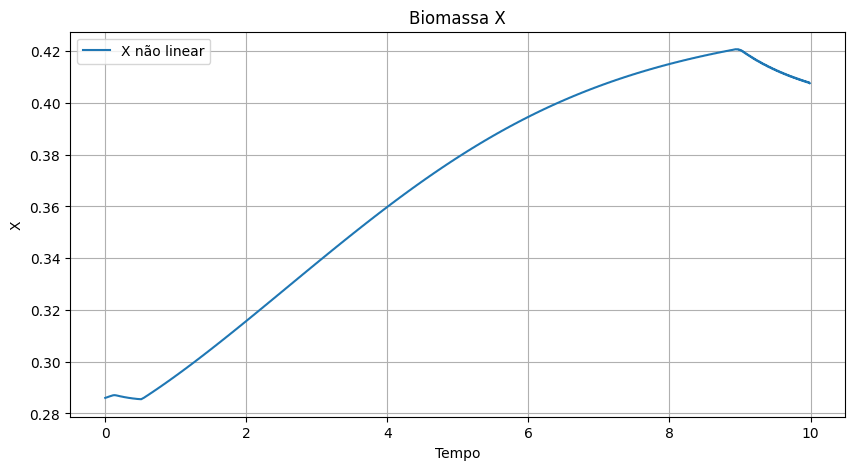

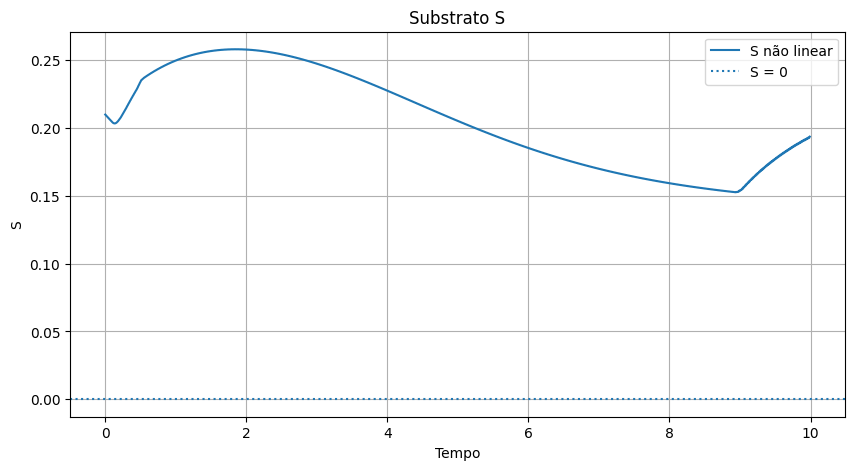

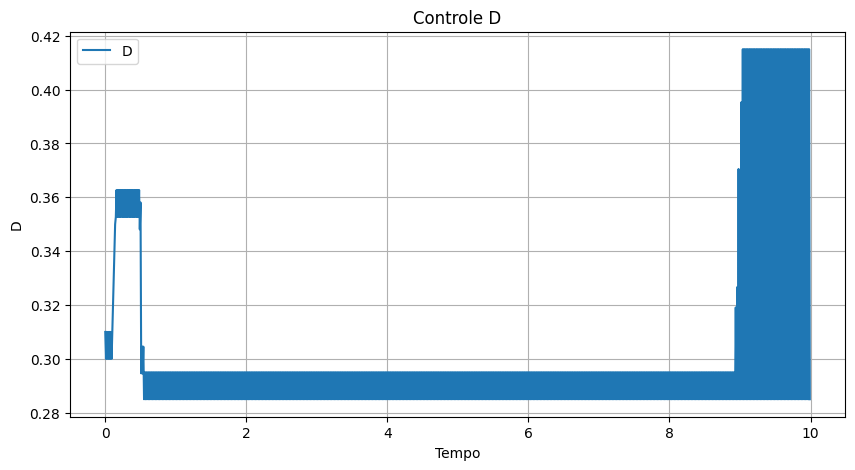

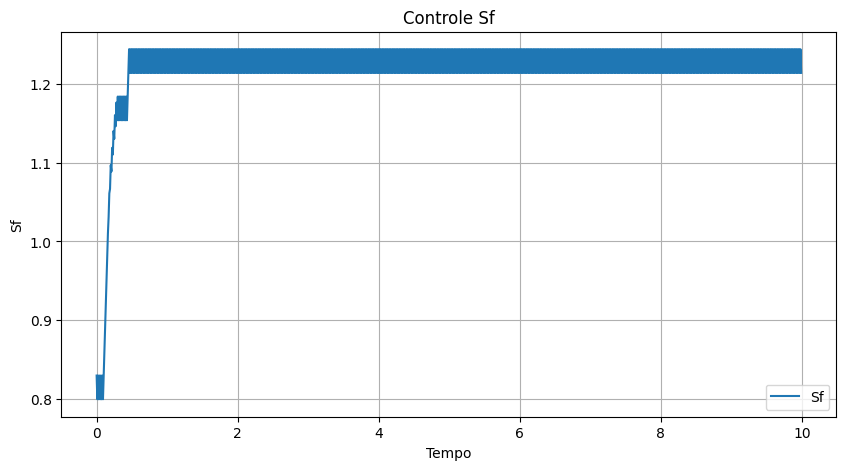

In [ ]:
Y_log = np.array(Y_log)          # modelo não linear: y_k = [X, S]
U_log = np.array(U_log)          # controle: u_k = [D, Sf]
Yhat_log = np.array(Yhat_log)    # previsão MPC: y_hat_next = [Xhat, Shat]

t = np.arange(len(Y_log)) * Ts

plt.figure(figsize=(10, 5))
plt.plot(t, Y_log[:, 0], label="X não linear")
# plt.plot(t, Yhat_log[:, 0], "--", label="X previsto MPC")
plt.xlabel("Tempo")
plt.ylabel("X")
plt.title("Biomassa X")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(t, Y_log[:, 1], label="S não linear")
# plt.plot(t, Yhat_log[:, 1], "--", label="S previsto MPC")
plt.axhline(0, linestyle=":", label="S = 0")
plt.xlabel("Tempo")
plt.ylabel("S")
plt.title("Substrato S")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(t, U_log[:, 0], label="D")
plt.xlabel("Tempo")
plt.ylabel("D")
plt.title("Controle D")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(t, U_log[:, 1], label="Sf")
plt.xlabel("Tempo")
plt.ylabel("Sf")
plt.title("Controle Sf")
plt.grid(True)
plt.legend()
plt.show()